In [42]:
# %autoreload 0


In [1]:
# Pretty inline figures
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import os, sys, math, json, pathlib, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx

# Where things live
sys.path += ["/nfs/team361/mv11/GGSD", "/nfs/team361/mv11/scgg/src"]
os.environ["PYG_DATASET_ROOT"] = "/nfs/team361/mv11/DATASETS/pyg"
EXP = pathlib.Path("/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline")
FIG = EXP / "figs"; (EXP/"logs").mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

# Make PyG load older pickles on PyTorch 2.6+
import torch.serialization as ts
from torch_geometric.data import Data, Batch
ts.add_safe_globals([Data, Batch])

import torch_geometric
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx

print("torch", torch.__version__, "| pyg", torch_geometric.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


torch 2.8.0+cu128 | pyg 2.5.3
cuda


PROTEINS (TU Dortmund, graph classification):

• Each graph = one protein (a contact graph of secondary-structure elements, SSEs).

• Nodes = SSEs (helix, sheet, turn). In PyG these come as 3-dim one-hot node features.

• Edges = two SSEs are spatially close (within a 3D distance threshold).

• Label y ∈ {0,1} = enzyme vs non-enzyme (binary graph label).

Goal in GGSD context: learn to GENERATE protein-like graphs whose global statistics (degree, clustering, spectrum) match the real dataset.

# Load PROTEINS & high-level overview

In [2]:
# PROTEINS (TUDataset): 1113 graphs.
# Nodes = secondary structure elements (SSE): helix/sheet/turn (3-dim one-hot in x).
# Edge = spatial contact between SSEs. Graph label y ∈ {0,1} (enzyme vs non-enzyme).

root = os.environ["PYG_DATASET_ROOT"]
ds = TUDataset(root=root, name="PROTEINS")
print(f"graphs={len(ds)}, node_feat_dim={ds.num_features}, num_classes={ds.num_classes}")

def pyg_to_nx(d):
    G = to_networkx(d, to_undirected=True)
    if d.x is not None:
        for i in range(d.num_nodes): G.nodes[i]["x"] = d.x[i].cpu().numpy()
    G.graph["y"] = int(d.y.item()) if d.y is not None else None
    return G


graphs=1113, node_feat_dim=3, num_classes=2


### Convert whole dataset to NetworkX & basic table

In [3]:
Gs = [pyg_to_nx(ds[i]) for i in range(len(ds))]

def graph_stats(G: nx.Graph):
    n = G.number_of_nodes(); m = G.number_of_edges()
    deg = np.array([d for _, d in G.degree()]) if n else np.array([0.])
    trans = nx.transitivity(G) if n>1 else np.nan
    ccs = list(nx.connected_components(G))
    return dict(
        n=n, m=m, density=(2*m)/(n*(n-1)) if n>1 else 0.0,
        deg_mean=deg.mean(), deg_med=float(np.median(deg)),
        trans=trans, n_cc=len(ccs), largest_cc=max((len(c) for c in ccs), default=0),
        y=G.graph.get('y', None)
    )

df = pd.DataFrame([graph_stats(G) for G in Gs])
display(df.describe().T.round(3))

# Save a csv summary
df.to_csv(EXP/"logs"/"proteins_dataset_summary.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
n,1113.0,39.058,45.779,4.000,15.000,26.000,45.000,620.000
m,1113.0,72.816,84.637,5.000,28.000,49.000,87.000,1049.000
density,1113.0,0.212,0.198,0.005,0.087,0.149,0.257,1.000
deg_mean,1113.0,3.735,0.424,1.714,3.477,3.677,4.000,5.071
deg_med,1113.0,3.582,0.601,1.000,3.000,4.000,4.000,5.000
trans,1113.0,0.476,0.201,0.000,0.302,0.530,0.618,1.000
n_cc,1113.0,1.078,0.520,1.000,1.000,1.000,1.000,9.000
largest_cc,1113.0,37.399,42.438,4.000,15.000,25.000,43.000,620.000
y,1113.0,0.404,0.491,0.000,0.000,0.000,1.000,1.000


How to read this:

- n, m, density tell you typical graph sizes/connectivity.

- deg_mean/deg_med ≈ average local connectivity.

- trans (transitivity) ≈ global clustering (triangle density).

- n_cc/largest_cc show connectivity (most graphs should be 1 component).

# Distributions that build intuition

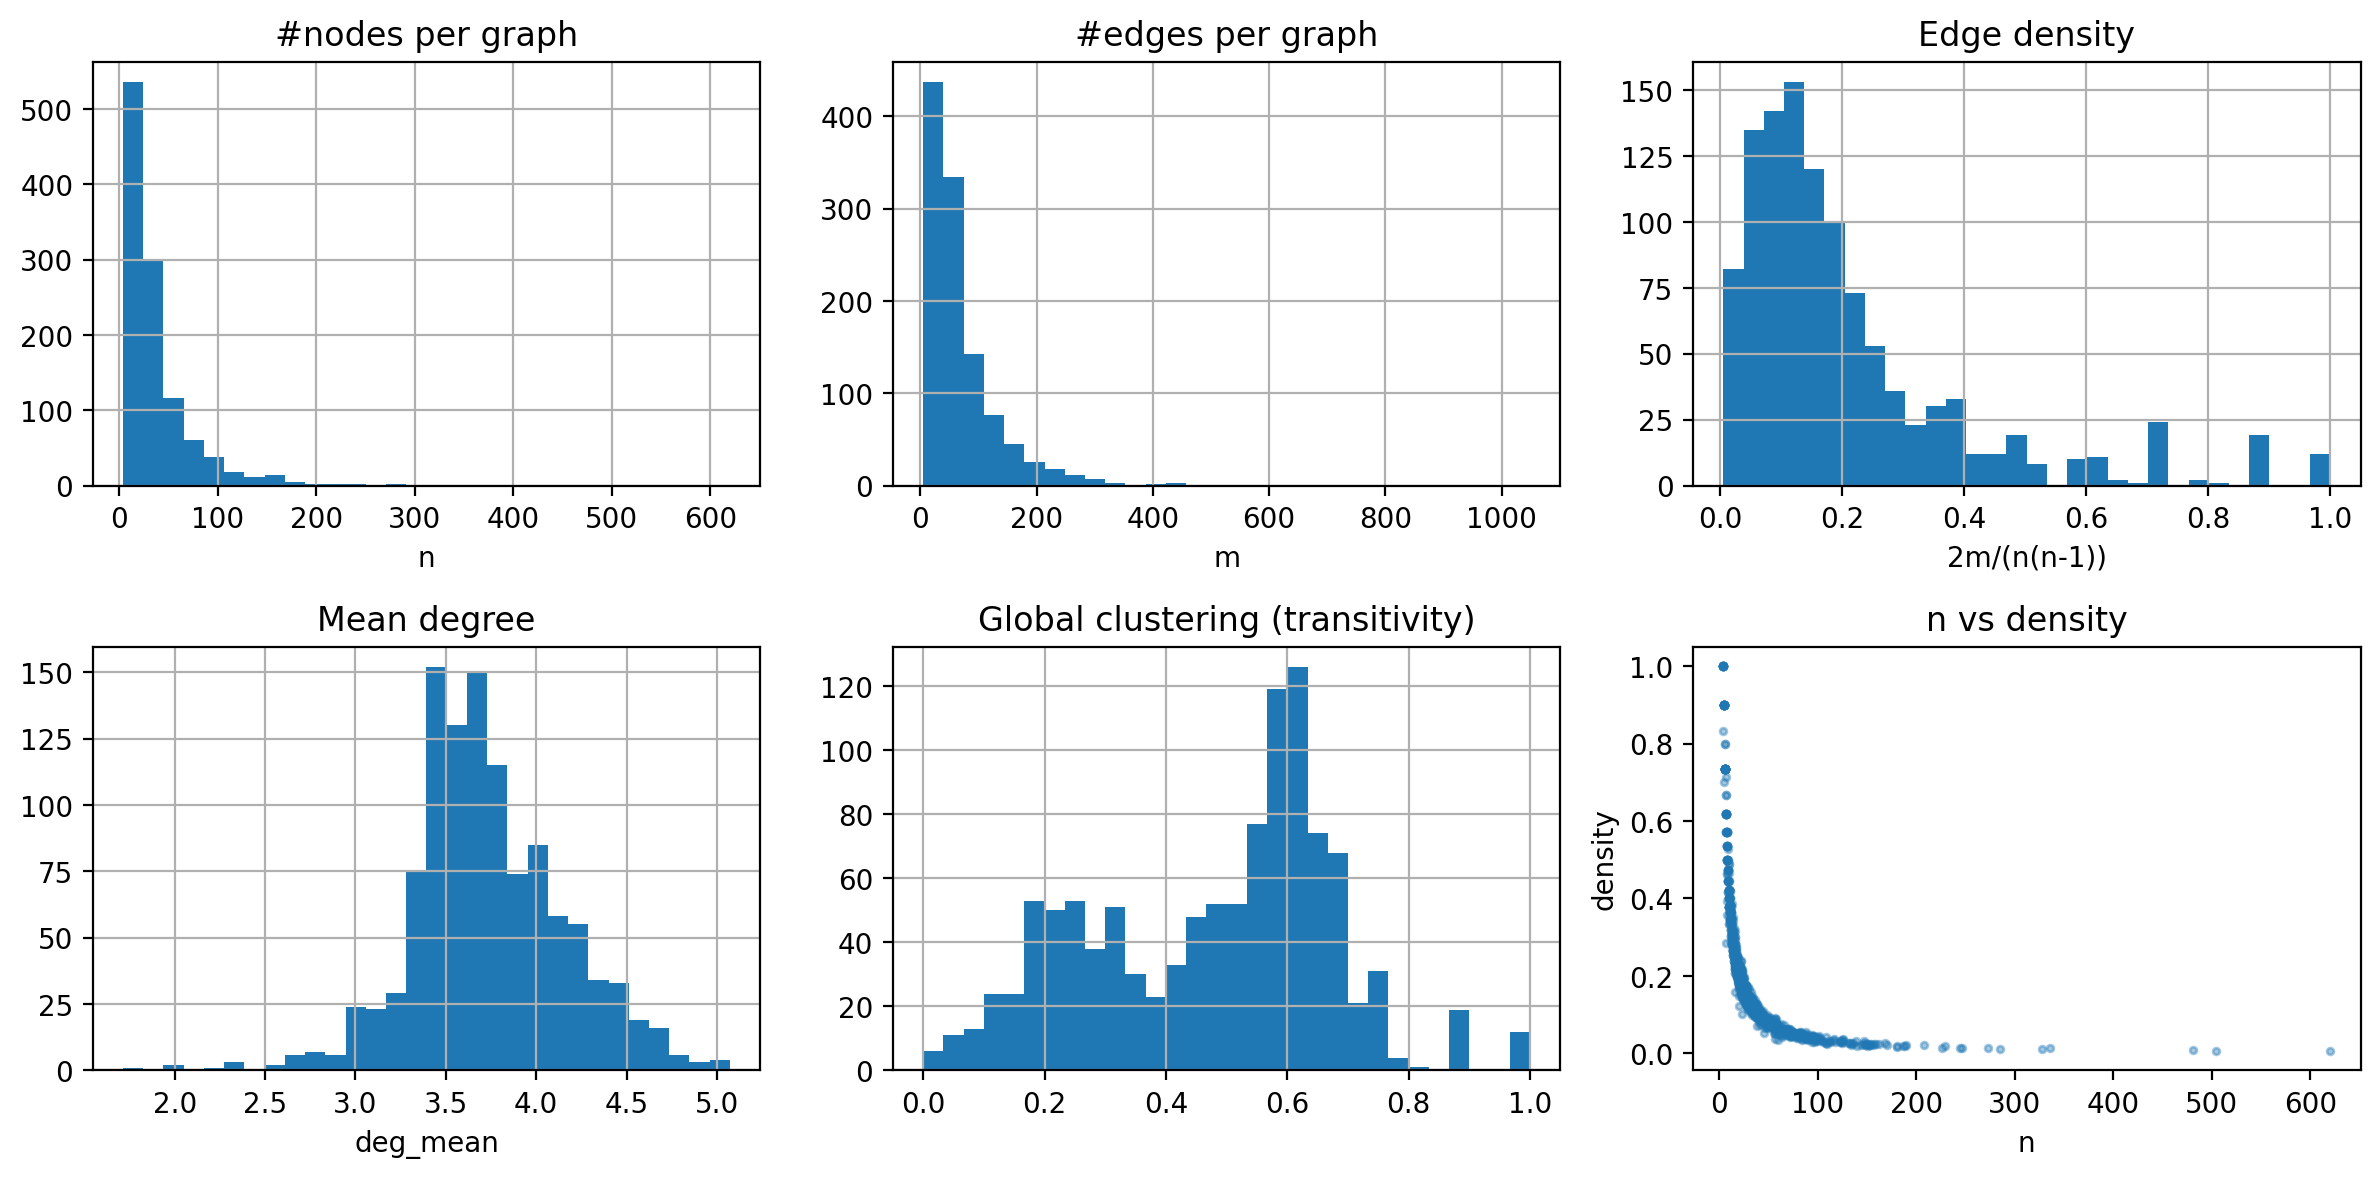

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(12,6))
df["n"].hist(bins=30, ax=axs[0,0]); axs[0,0].set_title("#nodes per graph"); axs[0,0].set_xlabel("n")
df["m"].hist(bins=30, ax=axs[0,1]); axs[0,1].set_title("#edges per graph"); axs[0,1].set_xlabel("m")
df["density"].hist(bins=30, ax=axs[0,2]); axs[0,2].set_title("Edge density"); axs[0,2].set_xlabel("2m/(n(n-1))")

df["deg_mean"].hist(bins=30, ax=axs[1,0]); axs[1,0].set_title("Mean degree"); axs[1,0].set_xlabel("deg_mean")
df["trans"].replace([np.inf, -np.inf], np.nan).dropna().hist(bins=30, ax=axs[1,1]); axs[1,1].set_title("Global clustering (transitivity)")
(axs[1,2].scatter(df["n"], df["density"], s=6, alpha=0.4)); axs[1,2].set_title("n vs density"); axs[1,2].set_xlabel("n"); axs[1,2].set_ylabel("density")
plt.tight_layout(); plt.show()


- PROTEINS graphs are small/medium (most n≈10–80, a few up to 600).

- Mean degree clustered ~3–4.

- Density drops with size (larger proteins are sparser).

- High clustering (transitivity) is typical for contact graphs.

# Node features & class balance

Node features shape: (43471, 3)
        min   mean  max
helix?  0.0  0.487  1.0
sheet?  0.0  0.481  1.0
turn?   0.0  0.032  1.0


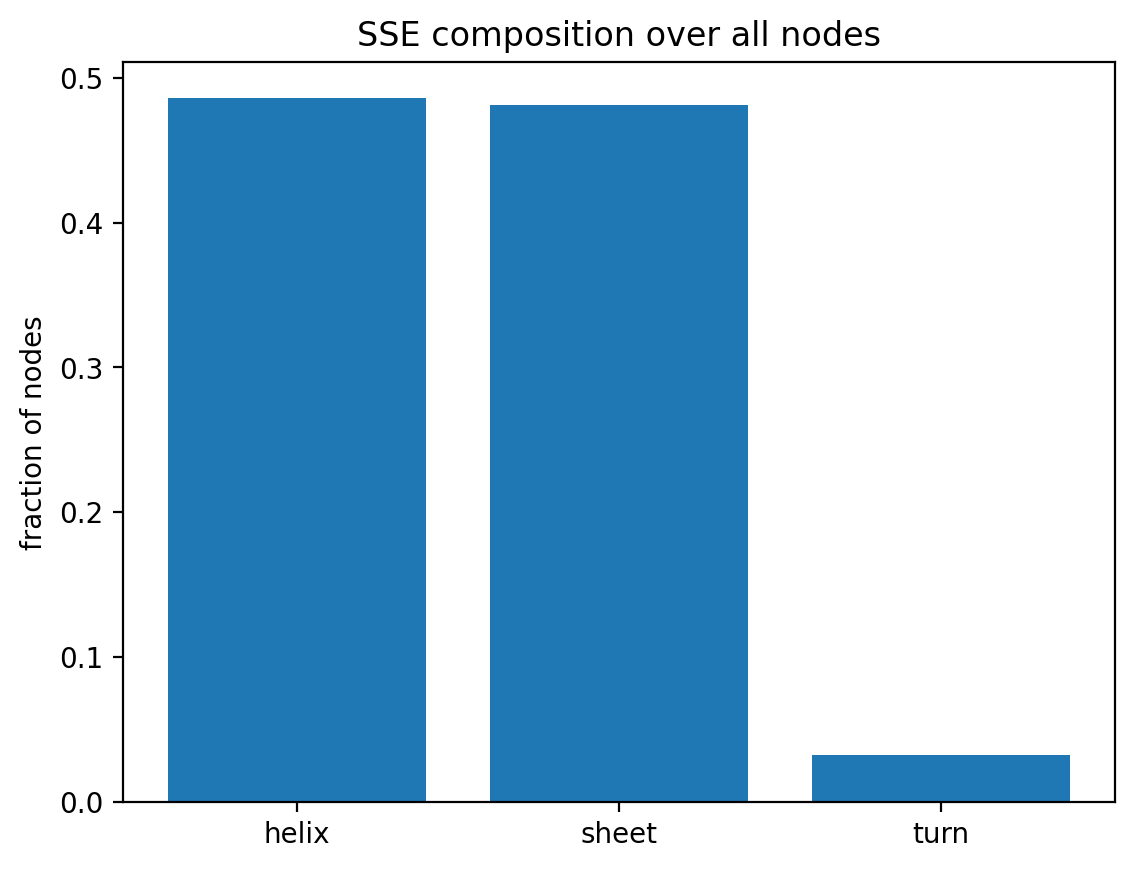

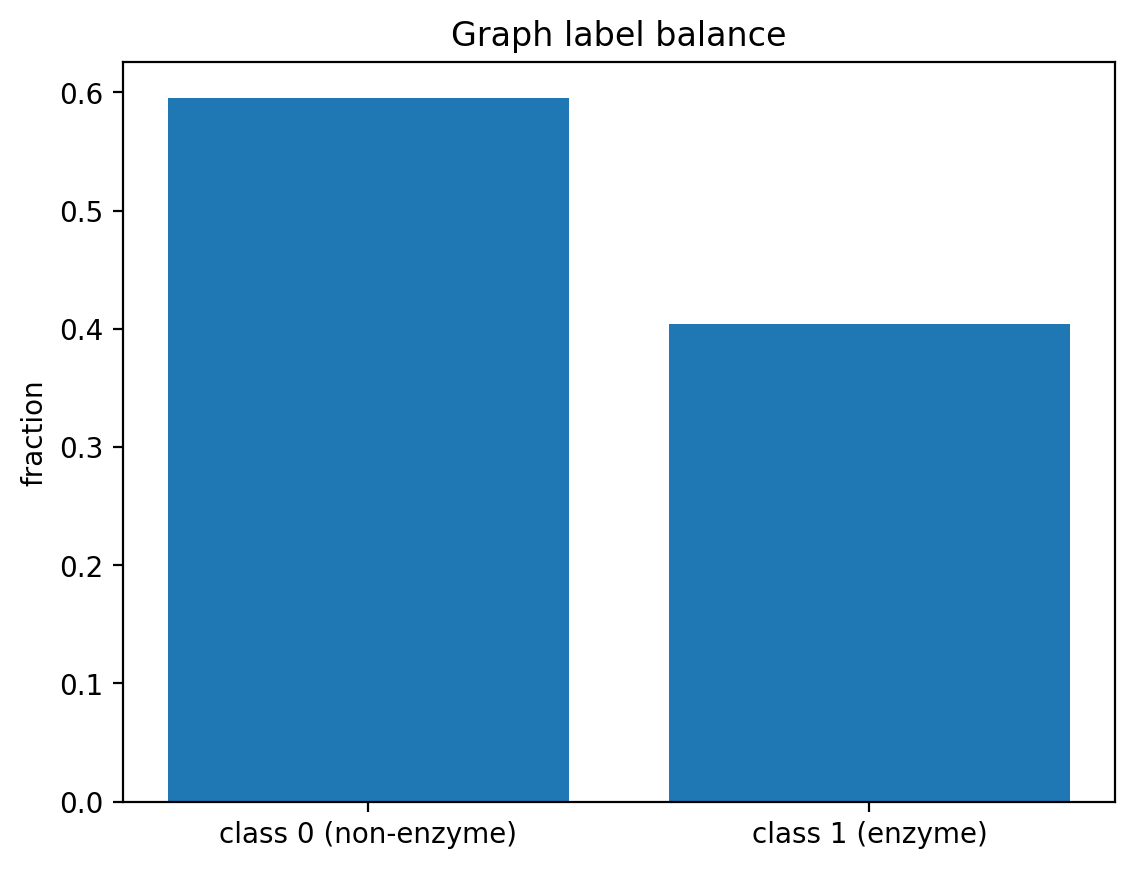

In [24]:
# Node features = three one-hot dims for SSE type (helix / sheet / turn)
X = np.vstack([G.nodes[i]['x'] for G in Gs for i in G.nodes()])  # (total_nodes, 3)
print("Node features shape:", X.shape)
print(pd.DataFrame({"min":X.min(0), "mean":X.mean(0), "max":X.max(0)}, index=["helix?","sheet?","turn?"]).round(3))

# Count SSE categories by argmax
cats = X.argmax(1)
plt.figure(); plt.bar([0,1,2], [np.mean(cats==k) for k in range(3)])
plt.xticks([0,1,2], ["helix","sheet","turn"]); plt.ylabel("fraction of nodes"); plt.title("SSE composition over all nodes")
plt.show()

# Class balance (graph labels)
ys = df["y"].dropna().astype(int).values
plt.figure(); plt.bar([0,1], [np.mean(ys==0), np.mean(ys==1)])
plt.xticks([0,1], ["class 0 (non-enzyme)","class 1 (enzyme)"]); plt.ylabel("fraction"); plt.title("Graph label balance")
plt.show()


# Meet a graph ! :))

Graph #0: n=42, m=81, mean_degree=3.86, transitivity=0.335


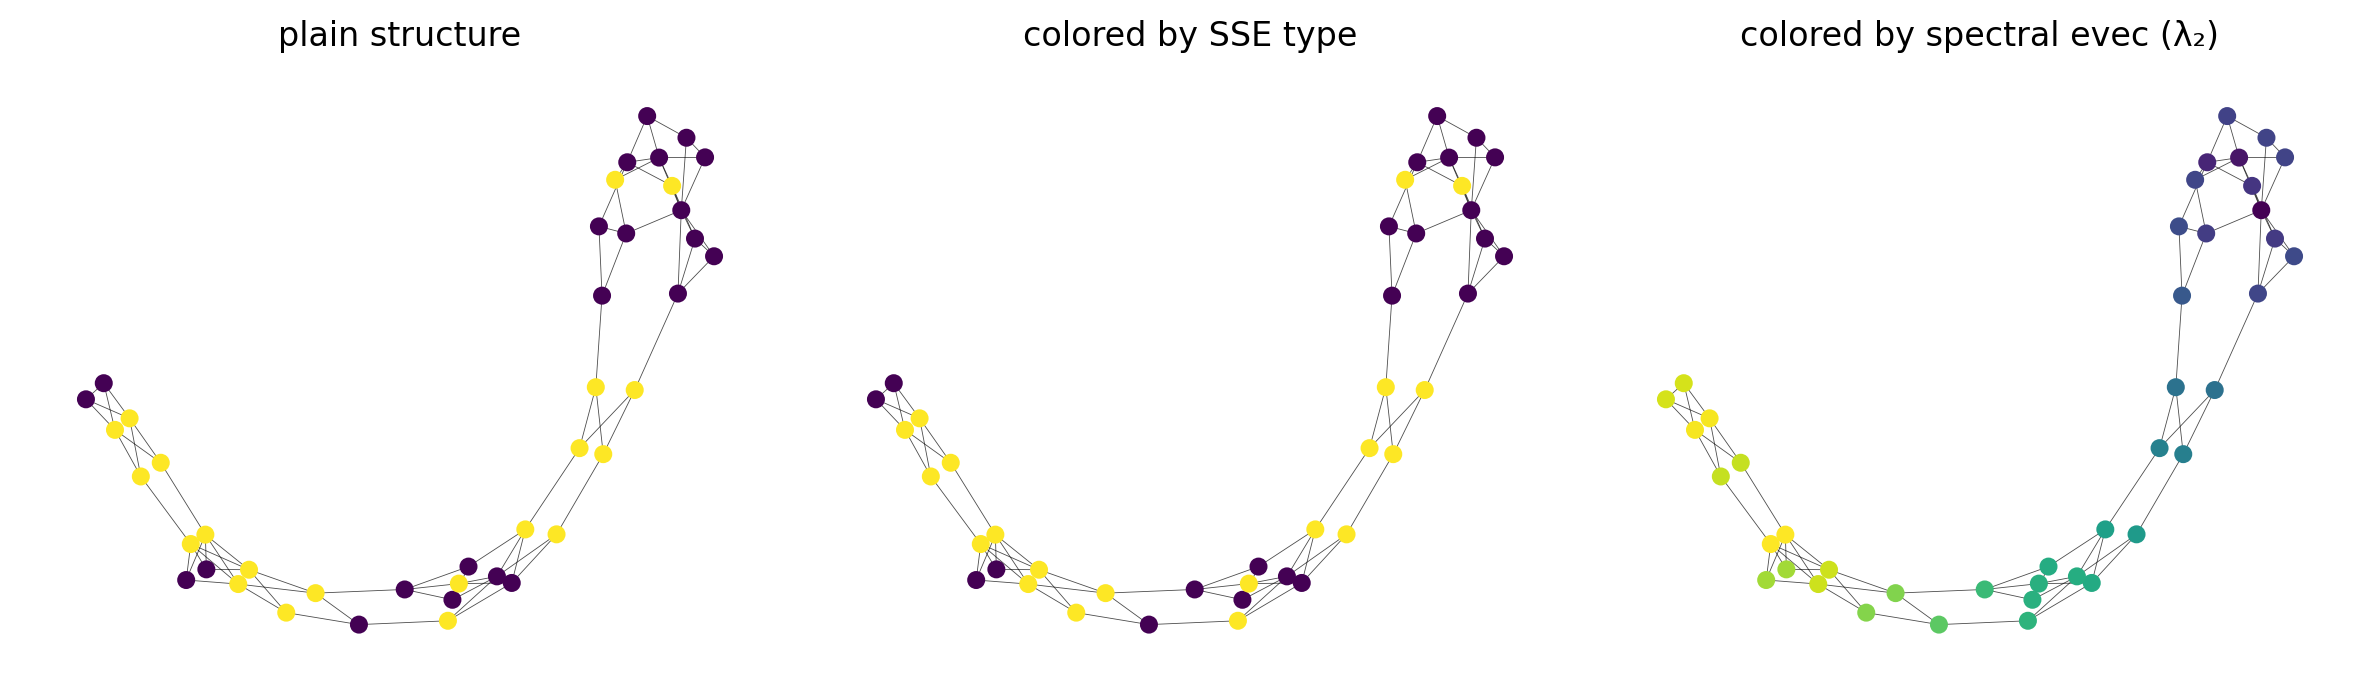

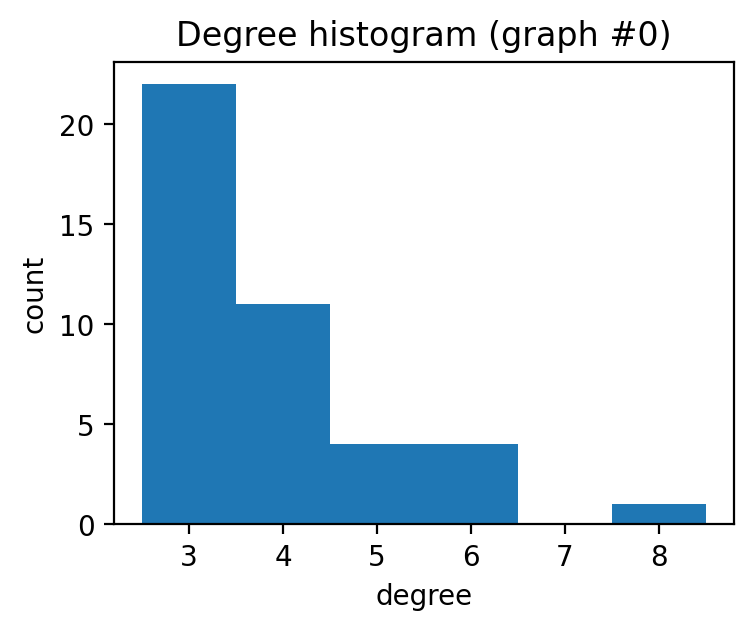

In [25]:
idx = 0
G = Gs[idx]
deg = np.array([d for _, d in G.degree()])
print(f"Graph #{idx}: n={G.number_of_nodes()}, m={G.number_of_edges()}, mean_degree={deg.mean():.2f}, transitivity={nx.transitivity(G):.3f}")

fig, axs = plt.subplots(1, 3, figsize=(12,3.6))
draw_graph(G, "plain structure", ax=axs[0])
draw_graph(G, "colored by SSE type", color_by="feature", ax=axs[1])
draw_graph(G, "colored by spectral evec (λ₂)", color_by="spectral", ax=axs[2])
plt.tight_layout(); plt.show()

# Degree histogram for the same graph
plt.figure(figsize=(4,3)); plt.hist(deg, bins=np.arange(deg.min(), deg.max()+2)-0.5); 
plt.xlabel("degree"); plt.ylabel("count"); plt.title(f"Degree histogram (graph #{idx})"); plt.show()


Why the Fiedler vector?

For the normalized Laplacian Lᵥ, eigenvalues lie in [0,2]. The multiplicity of 0 equals the number of connected components. The second eigenvector (Fiedler) highlights coarse “modules”/cuts. GGSD learns to denoise eigenpairs (Φ,λ) that look like those of real graphs.

# Spectral anatomy (what GGSD learns to denoise)

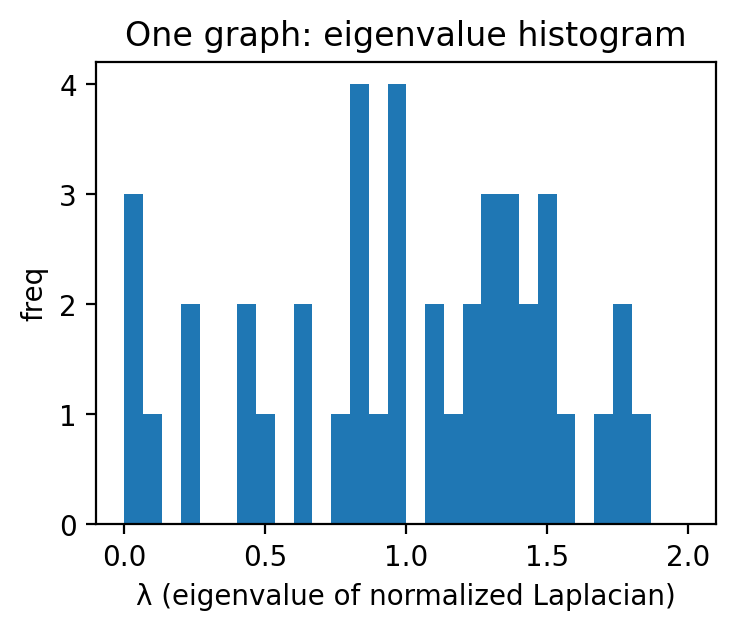

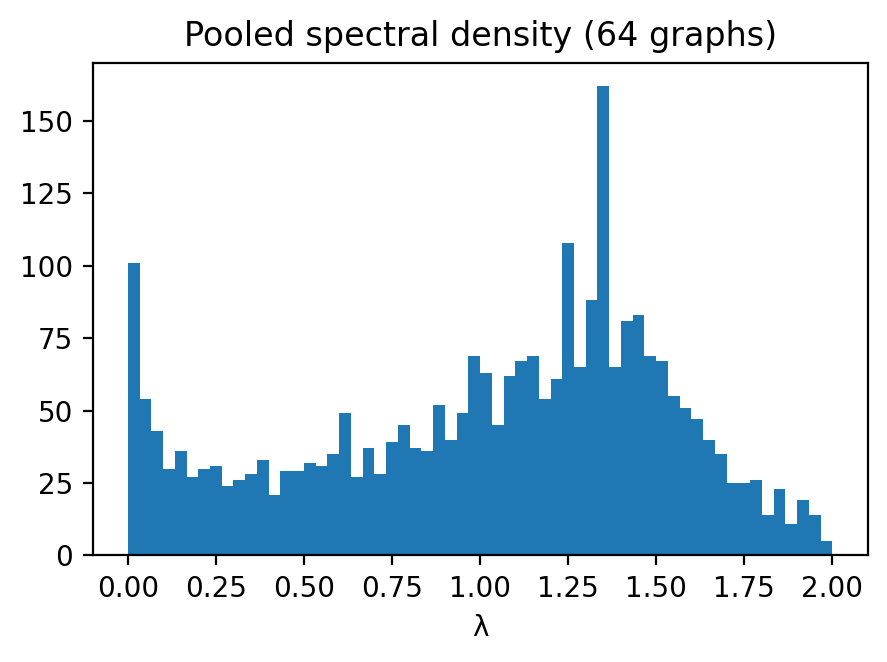

In [27]:
from numpy.linalg import eigh

def lap_spectrum(G):
    if G.number_of_nodes() < 2: return np.array([0.])
    L = nx.normalized_laplacian_matrix(G).toarray()
    w, U = eigh(L)      # eigenvalues in [0,2]
    return w, U

# show one spectrum
w, U = lap_spectrum(Gs[0])
plt.figure(figsize=(4,3)); plt.hist(w, bins=30, range=(0,2))
plt.xlabel("λ (eigenvalue of normalized Laplacian)"); plt.ylabel("freq")
plt.title("One graph: eigenvalue histogram"); plt.show()

# pooled spectral density from a sample of graphs
rng = np.random.default_rng(0)
sample_ids = rng.choice(len(Gs), size=64, replace=False)
pool = np.concatenate([lap_spectrum(Gs[i])[0] for i in sample_ids])
plt.figure(figsize=(5,3.2)); plt.hist(pool, bins=60, range=(0,2))
plt.xlabel("λ"); plt.title("Pooled spectral density (64 graphs)"); plt.show()


GGSD’s diffusion model learns a distribution over eigenpairs (Φ,λ). Matching the pooled spectrum is one way to check whether generated graphs “sound” like real ones.

# The evaluation metrics GGSD uses (with an ER baseline)

In [34]:
from utils.eval_helper import degree_stats, clustering_stats, spectral_stats

def er_like_real(G):
    """ER(n,p) with same n and density as G: simple 'fake' baseline."""
    n = G.number_of_nodes()
    if n < 2: return nx.empty_graph(n)
    p = (2*G.number_of_edges())/(n*(n-1))
    return nx.gnp_random_graph(n, p, seed=np.random.randint(1e9))

rng = np.random.default_rng(1)
real = [Gs[i] for i in rng.choice(len(Gs), size=300, replace=False)]
fake = [er_like_real(G) for G in real]  # baseline

deg_mmd = float(degree_stats(real, fake, is_parallel=True, compute_emd=False))
clu_mmd = float(clustering_stats(real, fake, is_parallel=True, compute_emd=False))
spe_mmd = float(spectral_stats(real, fake, is_parallel=True, n_eigvals=-1, compute_emd=False))

print("Baseline ER vs REAL — Maximum Mean Discrepancy (MMD; lower is better)")
print(json.dumps({"degree":deg_mmd, "clustering":clu_mmd, "spectral":spe_mmd}, indent=2))


Baseline ER vs REAL — Maximum Mean Discrepancy (MMD; lower is better)
{
  "degree": 0.07190076957188807,
  "clustering": 0.05015186605217671,
  "spectral": 0.04276863463820835
}


What these mean:

- degree MMD: gap between degree-distribution histograms (real vs generated).
  
- clustering MMD: gap between distributions of local clustering coefficients.
  
- spectral MMD: gap between Laplacian spectral densities (global structure).
  
MMD is 0 when the two distributions match exactly; values here (~0.04–0.07) are a
'how different' score, useful for RELATIVE comparison: diffusion→predictor should
beat this simple ER baseline by lowering all three numbers.

# Matrices behind a graph

Graph #0: n=42, m=81, mean degree=3.86, transitivity=0.335
Normalized Laplacian eigenvalues in [0,2]. Multiplicity of 0 = 1 (connected components).


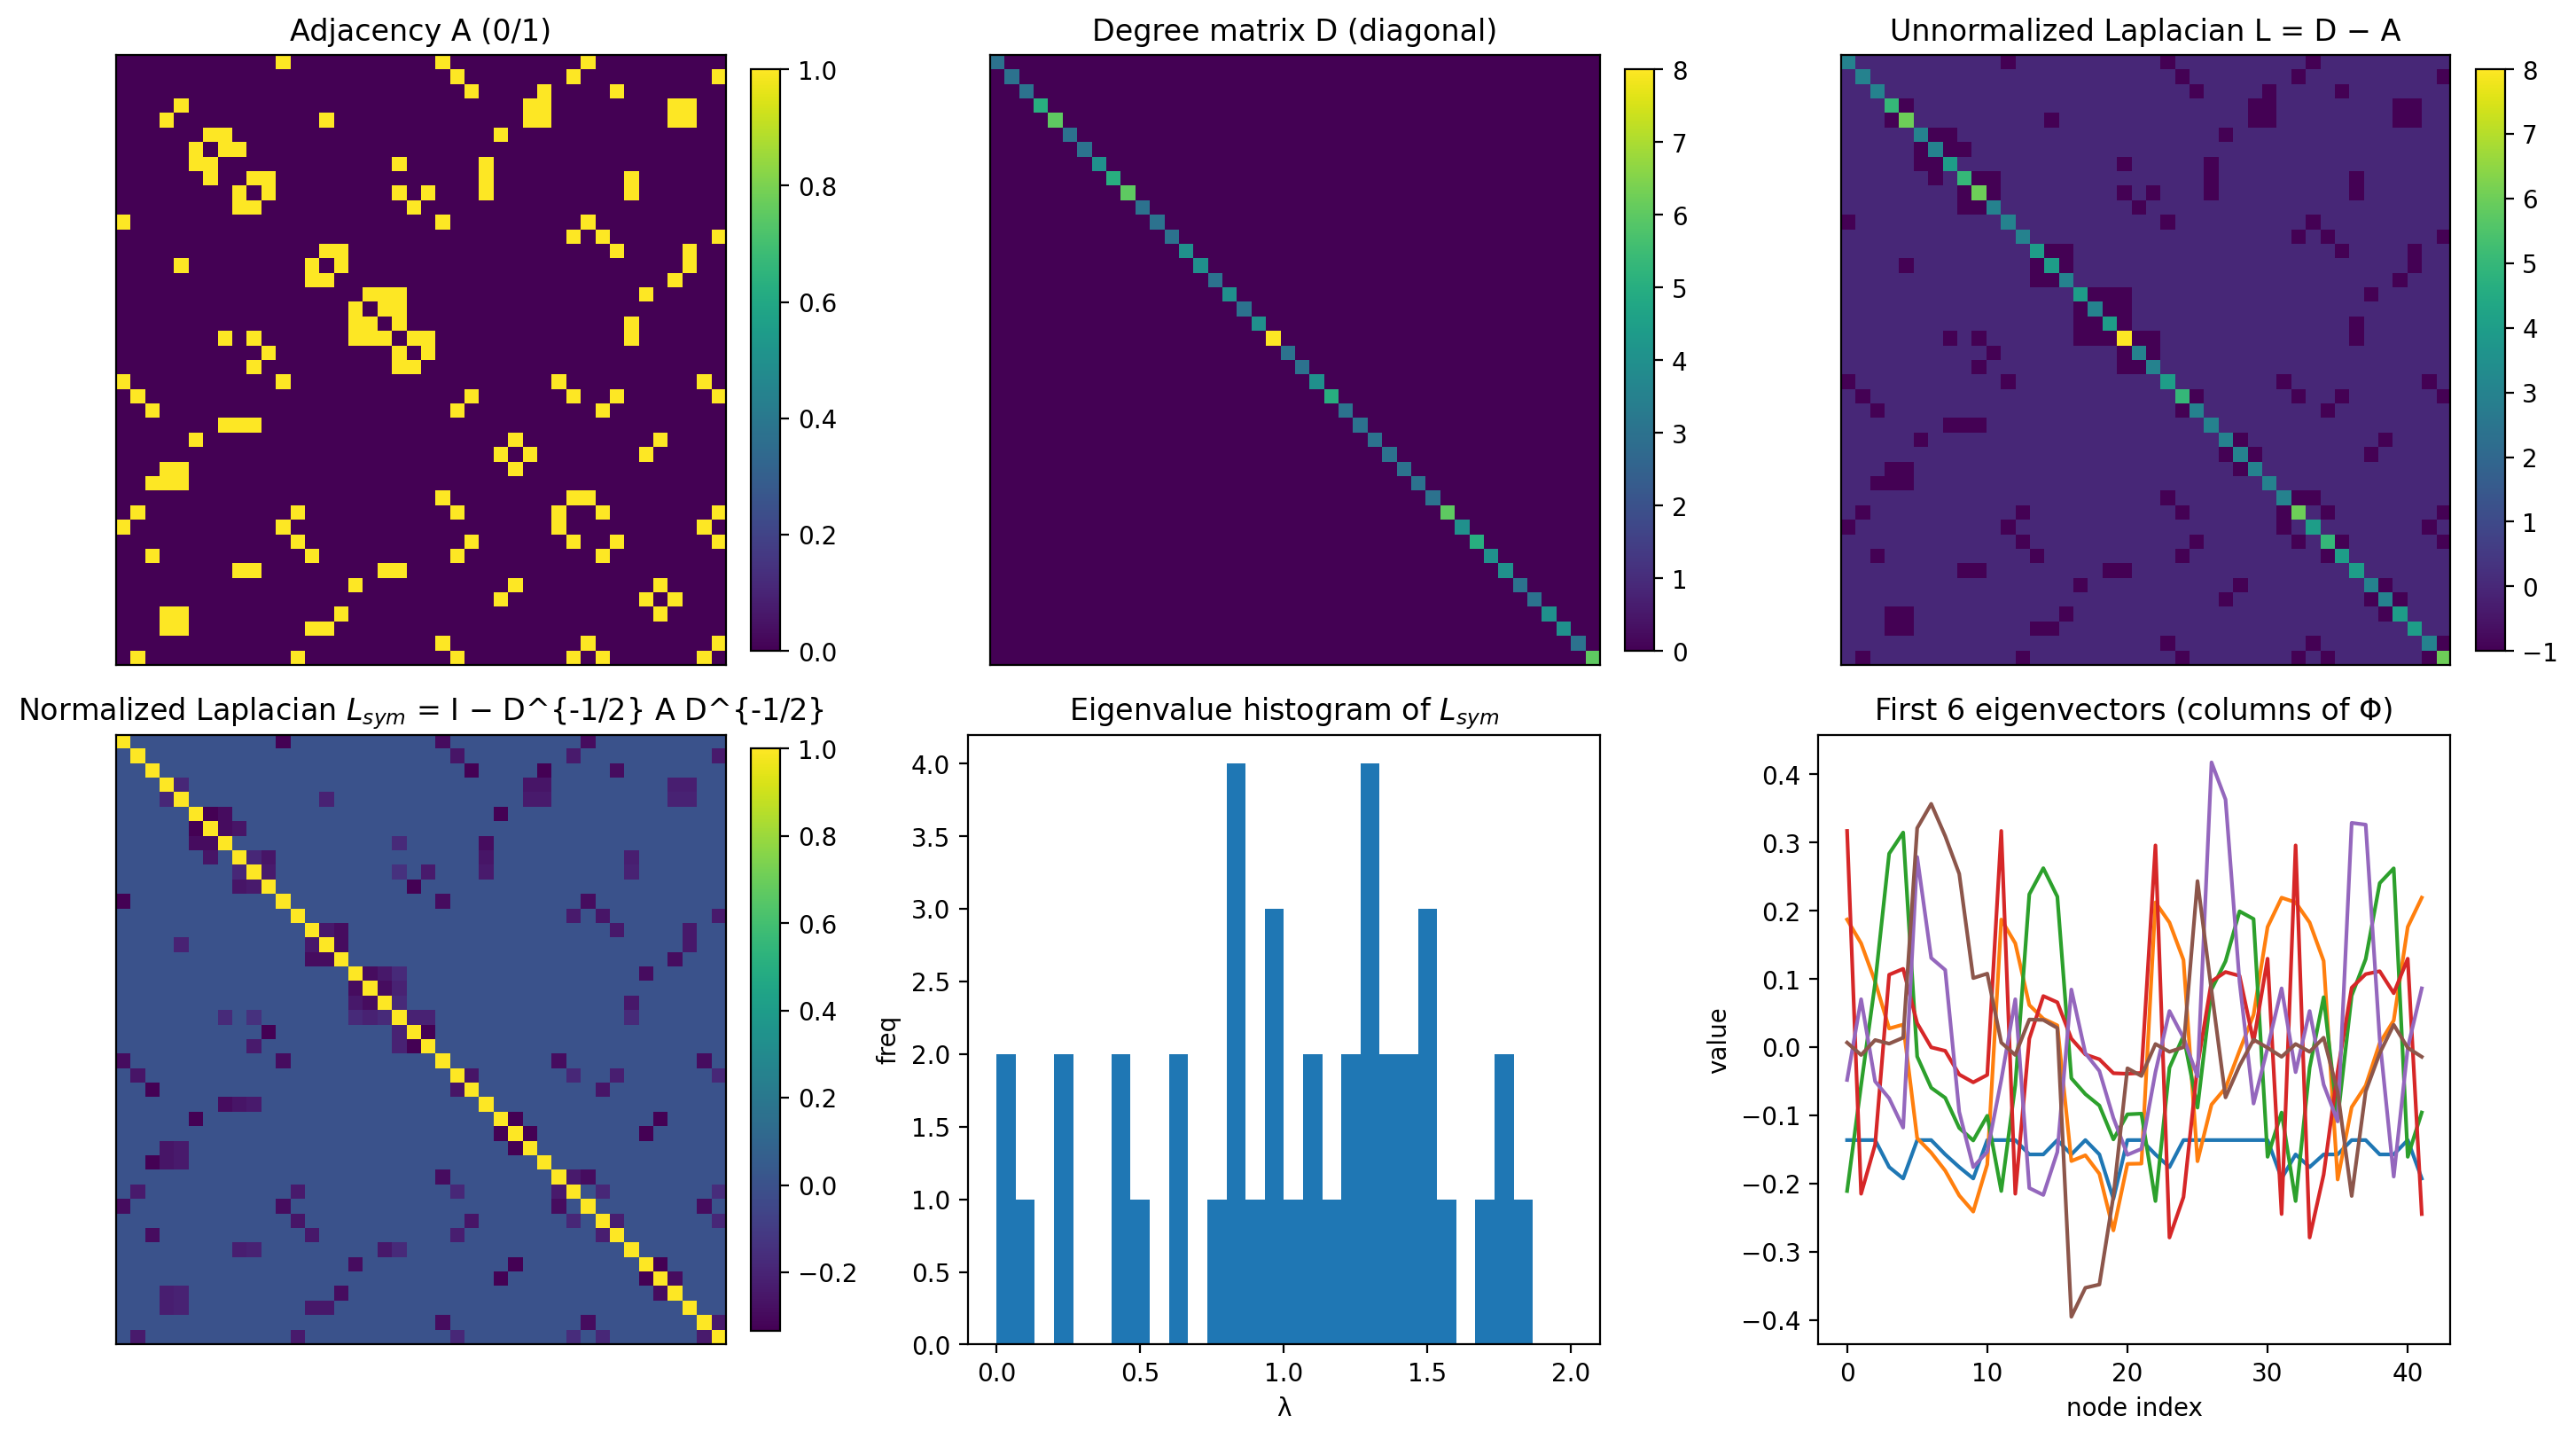

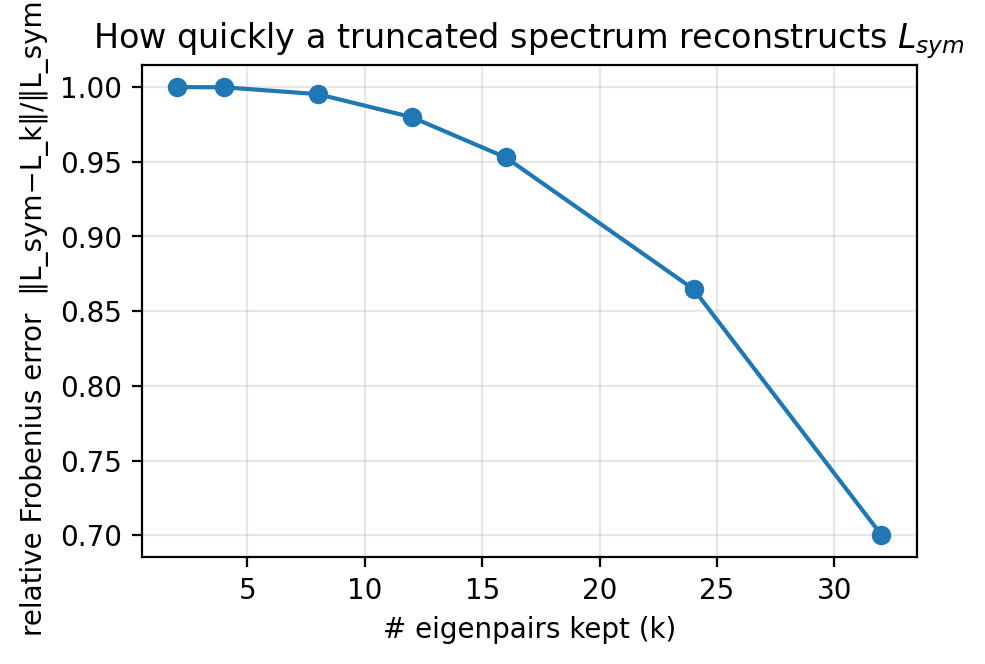

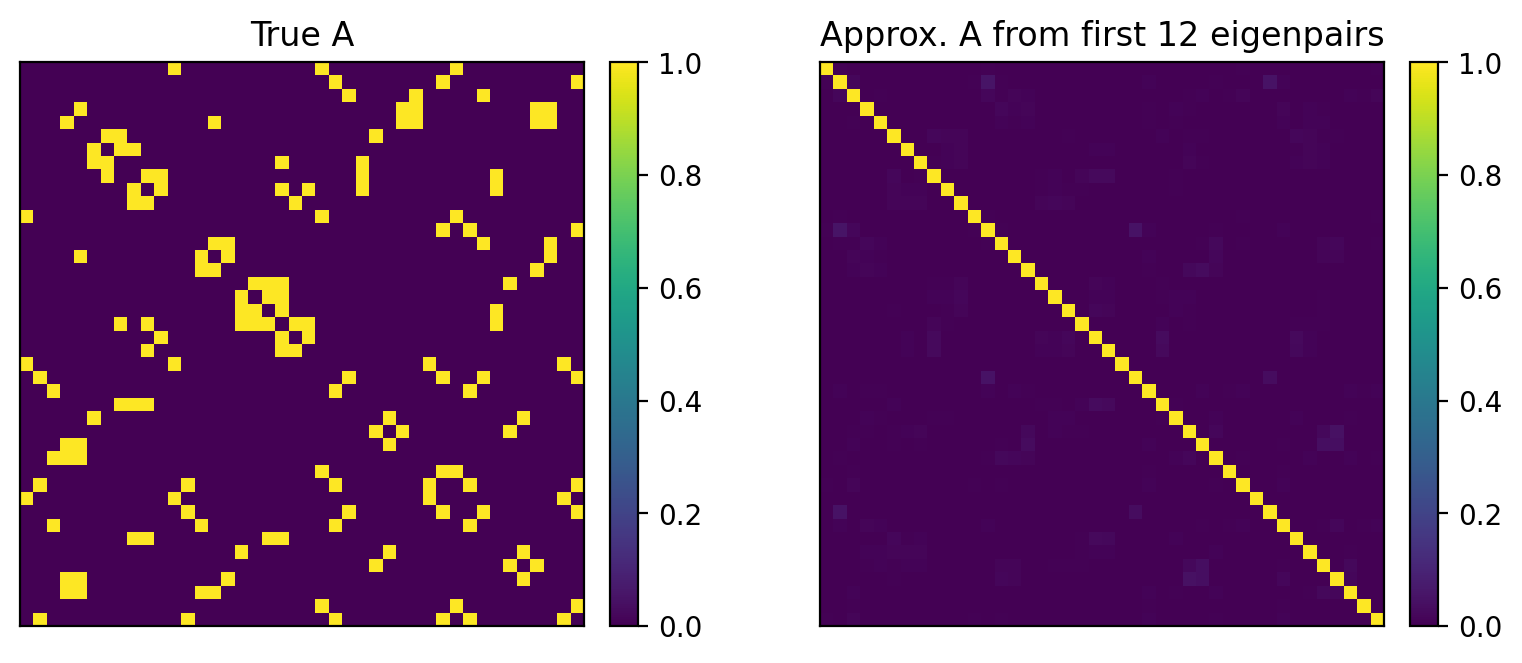

In [35]:
# pick a graph to inspect (same 'Gs' list you already built)
idx = 0
G = Gs[idx]
n = G.number_of_nodes()

# --- 1) core matrices --------------------------------------------------------
# adjacency (0/1, symmetric)
A = nx.to_numpy_array(G, dtype=float, nodelist=sorted(G.nodes()))

# degree vector and degree *matrix* (diagonal)
deg = A.sum(1)                         # shape (n,)
D = np.diag(deg)                       # shape (n, n)

# unnormalized Laplacian and normalized (symmetric) Laplacian
L = D - A

with np.errstate(divide='ignore'):
    Dm12 = np.diag(1.0 / np.sqrt(np.clip(deg, 1e-12, None)))
Lsym = np.eye(n) - Dm12 @ A @ Dm12     # eigenvalues in [0, 2]

# --- 2) spectrum -------------------------------------------------------------
# eigh -> symmetric matrices, returns ascending eigenvalues
w, U = np.linalg.eigh(Lsym)            # U[:, j] is eigenvector for w[j]
n_cc = np.sum(np.isclose(w, 0.0, atol=1e-12))  # #connected components

print(f"Graph #{idx}: n={n}, m={G.number_of_edges()}, "
      f"mean degree={deg.mean():.2f}, transitivity={nx.transitivity(G):.3f}")
print(f"Normalized Laplacian eigenvalues in [0,2]. "
      f"Multiplicity of 0 = {n_cc} (connected components).")

# --- 3) plotting helpers -----------------------------------------------------
def show_mat(M, ax, title):
    im = ax.imshow(M, interpolation="nearest", aspect="equal")
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- 4) panels: A, D, L, Lsym, spectrum, first k eigenvectors ---------------
k_show = min(6, n)

fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

show_mat(A,    axs[0,0], "Adjacency A (0/1)")
show_mat(D,    axs[0,1], "Degree matrix D (diagonal)")
show_mat(L,    axs[0,2], "Unnormalized Laplacian L = D − A")
show_mat(Lsym, axs[1,0], "Normalized Laplacian $L_{sym}$ = I − D^{-1/2} A D^{-1/2}")

# spectrum
axs[1,1].hist(w, bins=30, range=(0,2))
axs[1,1].set_title("Eigenvalue histogram of $L_{sym}$")
axs[1,1].set_xlabel("λ"); axs[1,1].set_ylabel("freq")

# first k eigenvectors (each column is a curve over nodes)
axs[1,2].plot(U[:, :k_show])
axs[1,2].set_title(f"First {k_show} eigenvectors (columns of Φ)")
axs[1,2].set_xlabel("node index"); axs[1,2].set_ylabel("value")
plt.show()

# --- 5) how many eigenpairs do we need? reconstruction error vs k -----------
# reconstruct Lsym from the first k eigenpairs: Lk = U_k diag(w_k) U_k^T
def recon_error_vs_k(w, U, Lsym, ks=(2,4,8,12,16,24,32)):
    ks = [k for k in ks if k <= len(w)]
    errs = []
    for k in ks:
        Uk = U[:, :k]
        Lk = (Uk * w[:k]) @ Uk.T       # same as Uk @ diag(w[:k]) @ Uk.T
        rel = np.linalg.norm(Lsym - Lk, 'fro') / np.linalg.norm(Lsym, 'fro')
        errs.append((k, rel))
    return np.array(errs)

errs = recon_error_vs_k(w, U, Lsym)
plt.figure(figsize=(5,3.2))
plt.plot(errs[:,0], errs[:,1], marker='o')
plt.xlabel("# eigenpairs kept (k)")
plt.ylabel("relative Frobenius error  ‖L_sym−L_k‖/‖L_sym‖")
plt.title("How quickly a truncated spectrum reconstructs $L_{sym}$")
plt.grid(True, alpha=0.3)
plt.show()

# --- 6) optional: visualize truncated adjacency guess -----------------------
# Using L = D − A  and L_k (from Lsym) to form a *crude* A_k.
# Note: this is only to build intuition; GGSD learns a predictor to refine this.
k = min(12, n)  # try a few values
Uk = U[:, :k]; Lk = (Uk * w[:k]) @ Uk.T
# go back from L_sym to L: L = D^{1/2} L_sym D^{1/2}
Lk_un = Dm12 @ Lk @ Dm12
Ak = D - Lk_un
Ak = np.clip(Ak, 0, 1)                 # clip just for visualization
fig, ax = plt.subplots(1,2, figsize=(8,3.2), constrained_layout=True)
show_mat(A,  ax[0], "True A")
show_mat(Ak, ax[1], f"Approx. A from first {k} eigenpairs")
plt.show()


In [ ]:
# pick a graph to inspect (same 'Gs' list you already built)
idx = 0
G = Gs[idx]
n = G.number_of_nodes()

# --- 1) core matrices --------------------------------------------------------
# adjacency (0/1, symmetric)
A = nx.to_numpy_array(G, dtype=float, nodelist=sorted(G.nodes()))

# degree vector and degree *matrix* (diagonal)
deg = A.sum(1)                         # shape (n,)
D = np.diag(deg)                       # shape (n, n)

# unnormalized Laplacian and normalized (symmetric) Laplacian
L = D - A

with np.errstate(divide='ignore'):
    Dm12 = np.diag(1.0 / np.sqrt(np.clip(deg, 1e-12, None)))
Lsym = np.eye(n) - Dm12 @ A @ Dm12     # eigenvalues in [0, 2]

# --- 2) spectrum -------------------------------------------------------------
# eigh -> symmetric matrices, returns ascending eigenvalues
w, U = np.linalg.eigh(Lsym)            # U[:, j] is eigenvector for w[j]
n_cc = np.sum(np.isclose(w, 0.0, atol=1e-12))  # #connected components

print(f"Graph #{idx}: n={n}, m={G.number_of_edges()}, "
      f"mean degree={deg.mean():.2f}, transitivity={nx.transitivity(G):.3f}")
print(f"Normalized Laplacian eigenvalues in [0,2]. "
      f"Multiplicity of 0 = {n_cc} (connected components).")

# --- 3) plotting helpers -----------------------------------------------------
def show_mat(M, ax, title):
    im = ax.imshow(M, interpolation="nearest", aspect="equal")
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- 4) panels: A, D, L, Lsym, spectrum, first k eigenvectors ---------------
k_show = min(6, n)

fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

show_mat(A,    axs[0,0], "Adjacency A (0/1)")
show_mat(D,    axs[0,1], "Degree matrix D (diagonal)")
show_mat(L,    axs[0,2], "Unnormalized Laplacian L = D − A")
show_mat(Lsym, axs[1,0], "Normalized Laplacian $L_{sym}$ = I − D^{-1/2} A D^{-1/2}")

# spectrum
axs[1,1].hist(w, bins=30, range=(0,2))
axs[1,1].set_title("Eigenvalue histogram of $L_{sym}$")
axs[1,1].set_xlabel("λ"); axs[1,1].set_ylabel("freq")

# first k eigenvectors (each column is a curve over nodes)
axs[1,2].plot(U[:, :k_show])
axs[1,2].set_title(f"First {k_show} eigenvectors (columns of Φ)")
axs[1,2].set_xlabel("node index"); axs[1,2].set_ylabel("value")
plt.show()

# --- 5) how many eigenpairs do we need? reconstruction error vs k -----------
# reconstruct Lsym from the first k eigenpairs: Lk = U_k diag(w_k) U_k^T
def recon_error_vs_k(w, U, Lsym, ks=(2,4,8,12,16,24,32)):
    ks = [k for k in ks if k <= len(w)]
    errs = []
    for k in ks:
        Uk = U[:, :k]
        Lk = (Uk * w[:k]) @ Uk.T       # same as Uk @ diag(w[:k]) @ Uk.T
        rel = np.linalg.norm(Lsym - Lk, 'fro') / np.linalg.norm(Lsym, 'fro')
        errs.append((k, rel))
    return np.array(errs)

errs = recon_error_vs_k(w, U, Lsym)
plt.figure(figsize=(5,3.2))
plt.plot(errs[:,0], errs[:,1], marker='o')
plt.xlabel("# eigenpairs kept (k)")
plt.ylabel("relative Frobenius error  ‖L_sym−L_k‖/‖L_sym‖")
plt.title("How quickly a truncated spectrum reconstructs $L_{sym}$")
plt.grid(True, alpha=0.3)
plt.show()

# --- 6) optional: visualize truncated adjacency guess -----------------------
# Using L = D − A  and L_k (from Lsym) to form a *crude* A_k.
# Note: this is only to build intuition; GGSD learns a predictor to refine this.
k = min(12, n)  # try a few values
Uk = U[:, :k]; Lk = (Uk * w[:k]) @ Uk.T
# go back from L_sym to L: L = D^{1/2} L_sym D^{1/2}
Lk_un = Dm12 @ Lk @ Dm12
Ak = D - Lk_un
Ak = np.clip(Ak, 0, 1)                 # clip just for visualization
fig, ax = plt.subplots(1,2, figsize=(8,3.2), constrained_layout=True)
show_mat(A,  ax[0], "True A")
show_mat(Ak, ax[1], f"Approx. A from first {k} eigenpairs")
plt.show()


what each panel teaches

A: which residues (nodes) are in contact (edge = 1).

D: the node degrees on the diagonal. You’ll see higher values along diagonal blocks where there are dense substructures.

L = D−A: encodes cuts; rows sum to zero.

𝐿 𝑠𝑦𝑚: a normalized version whose eigenvalues live in [0,2].

– the number of zeros equals the number of connected components.

– the eigenvector for the 2nd smallest eigenvalue (the Fiedler vector) often highlights a coarse split of the graph (you already used it as a color map).

First k eigenvectors: each column is a smooth signal over nodes; low-frequency ones vary slowly and capture global structure, high-frequency ones capture local detail.

Reconstruction error vs k: why GGSD can truncate the spectrum — you typically recover most of 𝐿 𝑠𝑦𝑚 with relatively few eigenpairs.

Graph #0: n=42, m=81, mean degree=3.86, transitivity=0.335
L_sym eigenvalues in [0,2]; multiplicity of 0 = 1 (components).


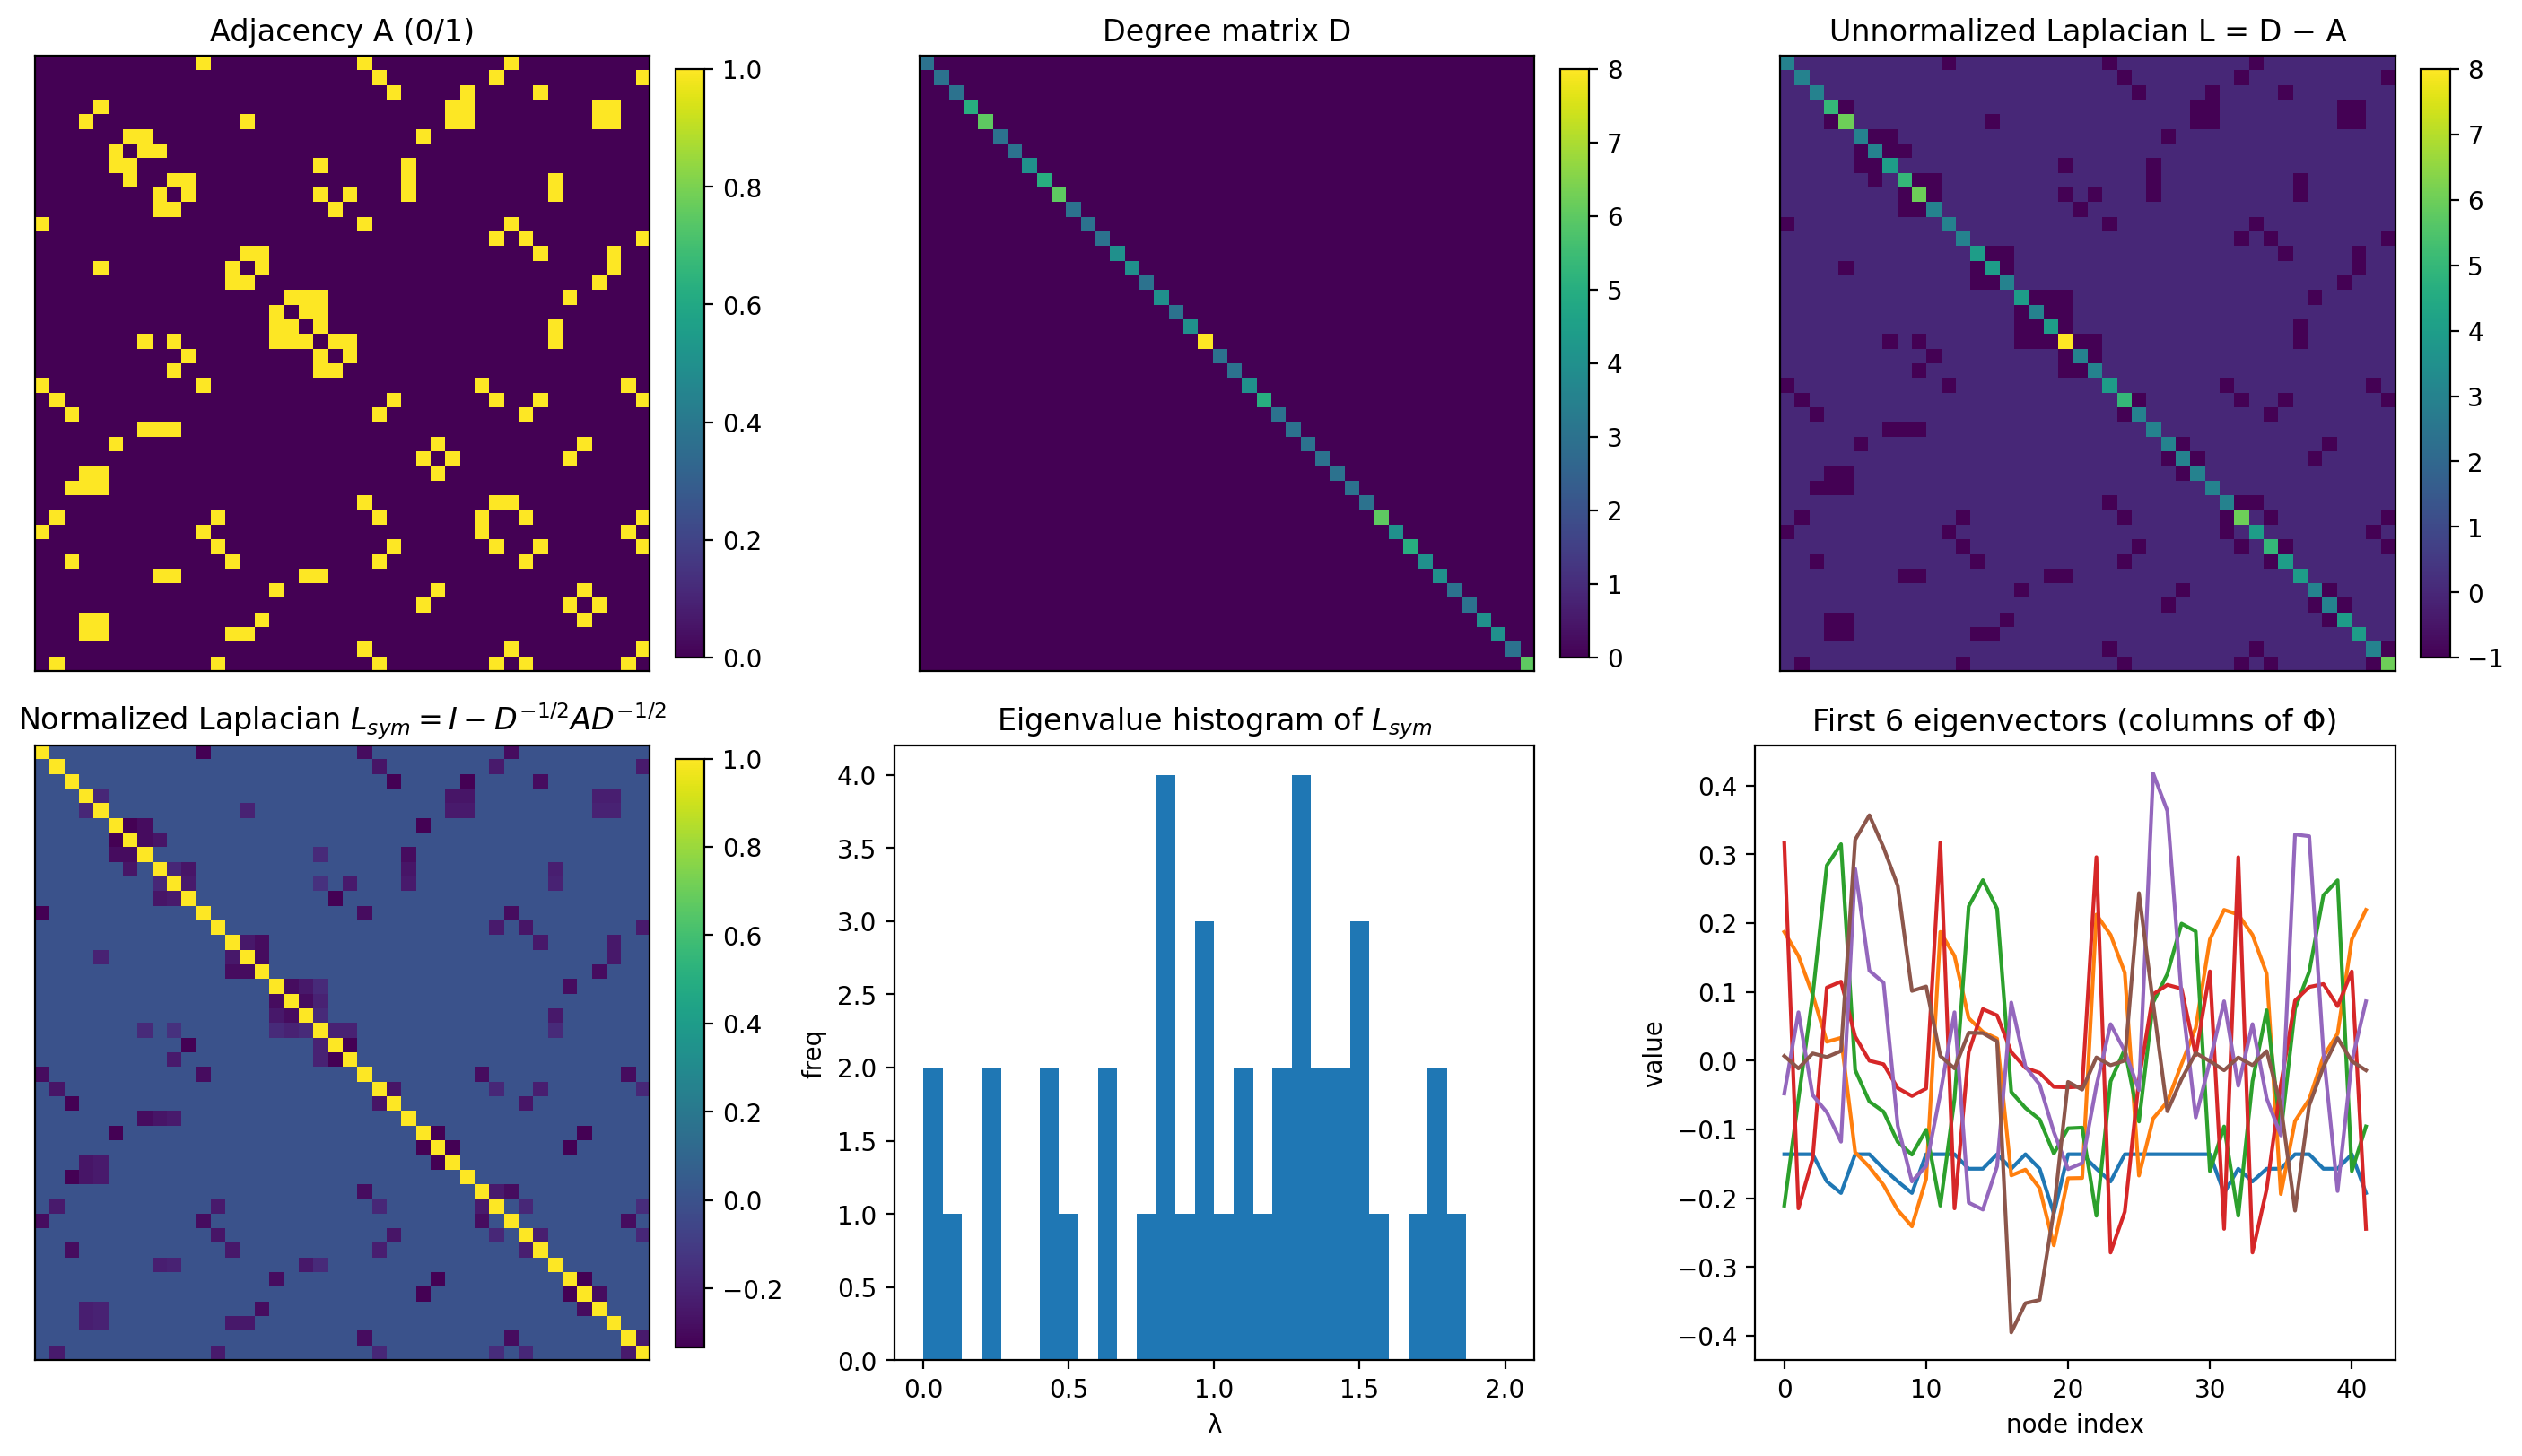

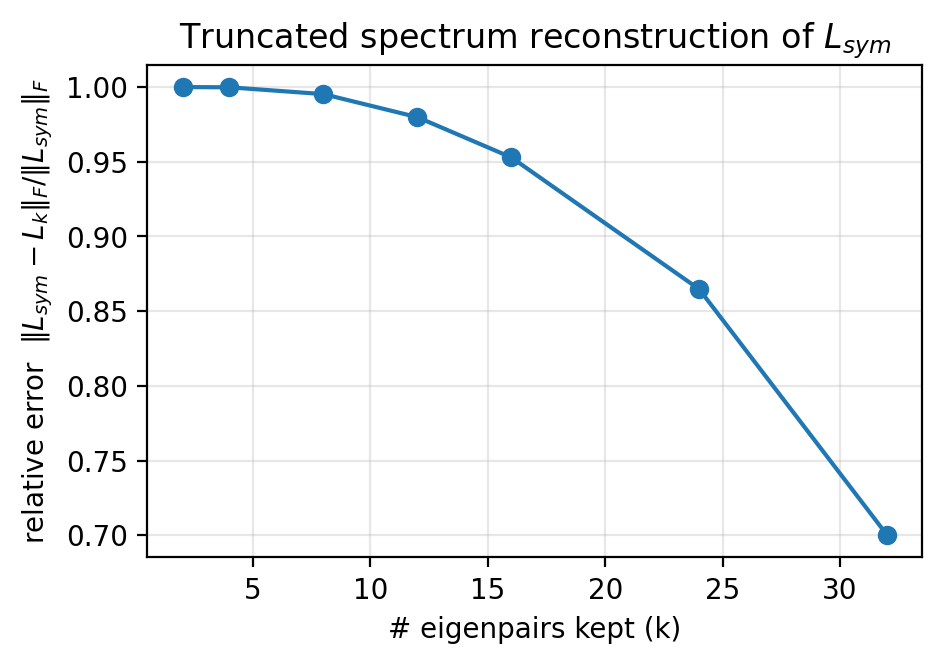

k = 12


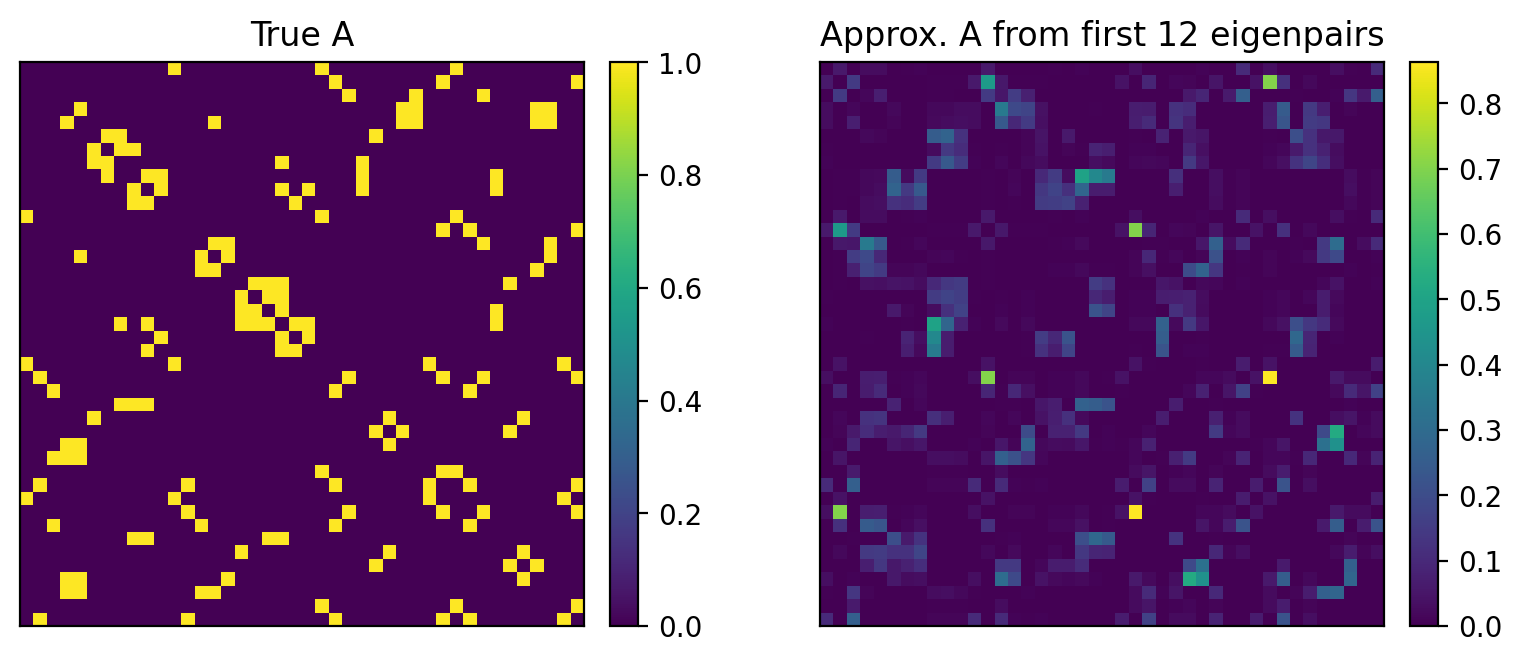

k = 30


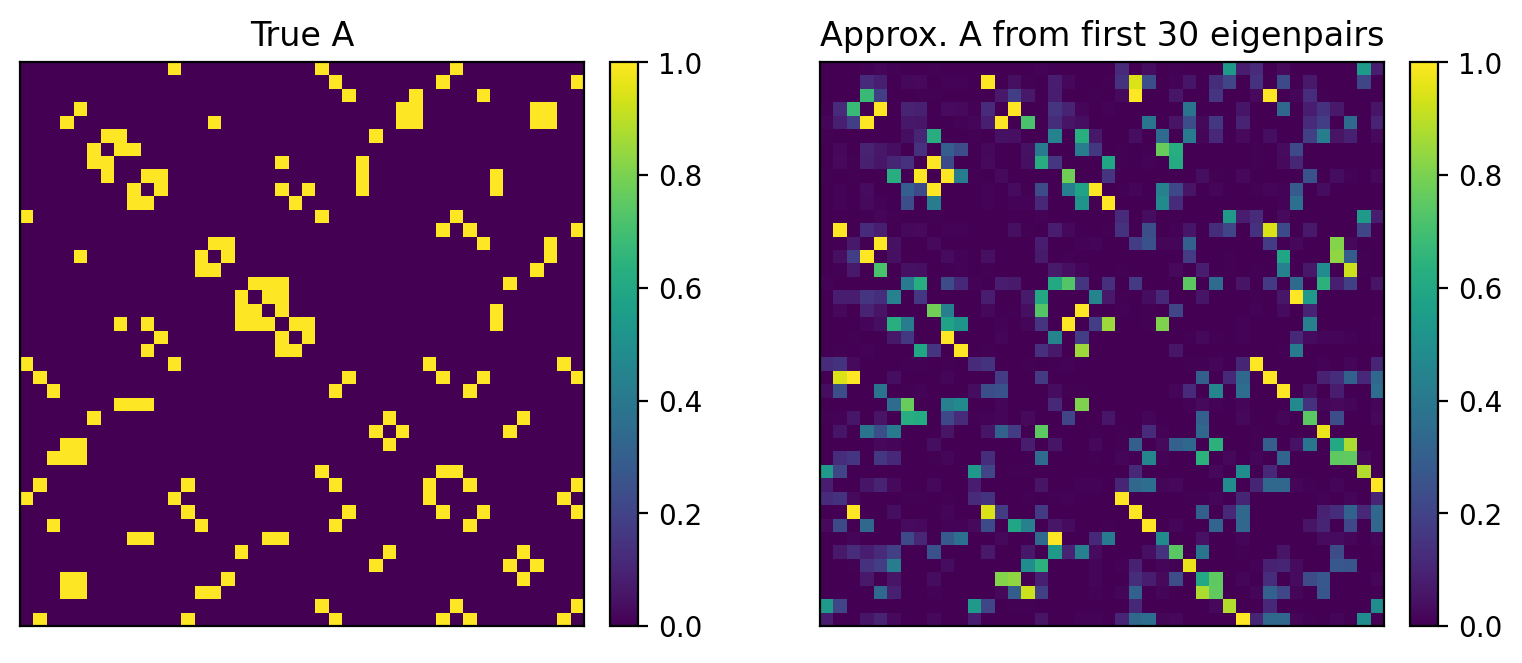

k = 50


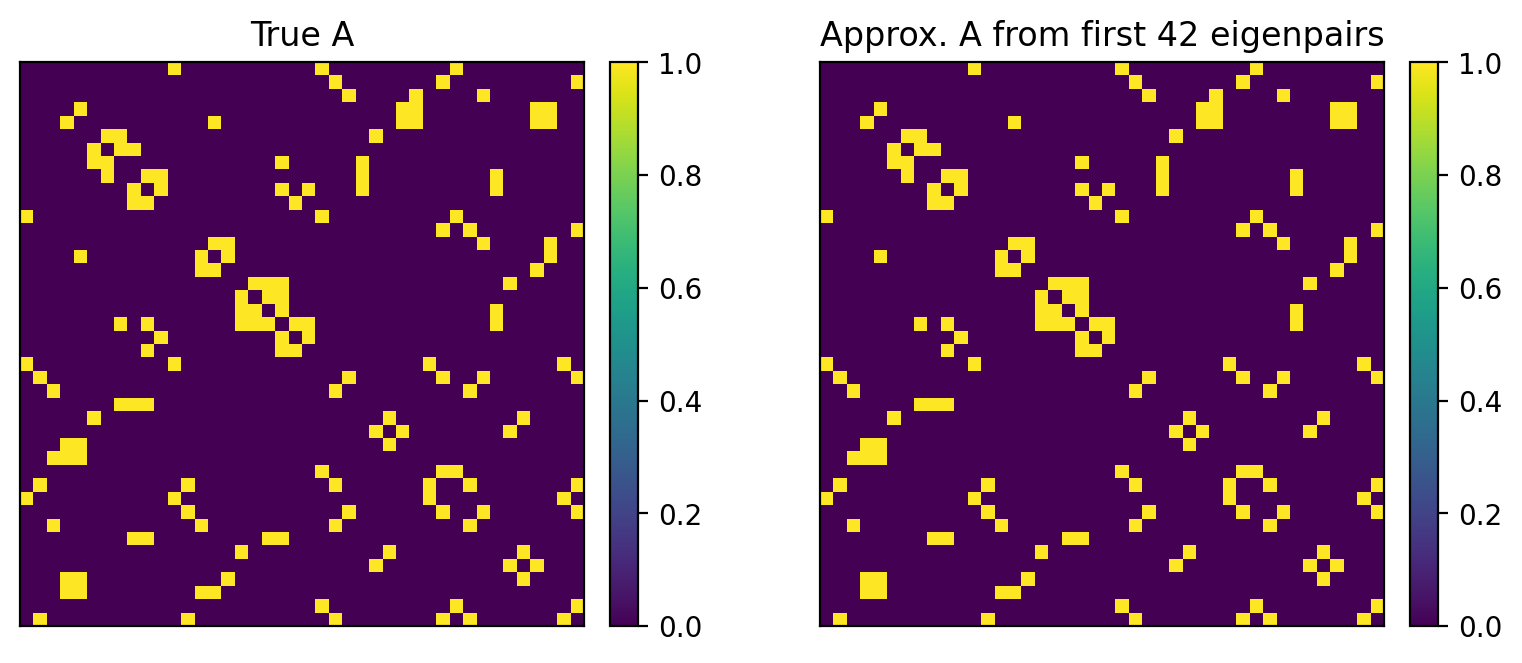

k = 100


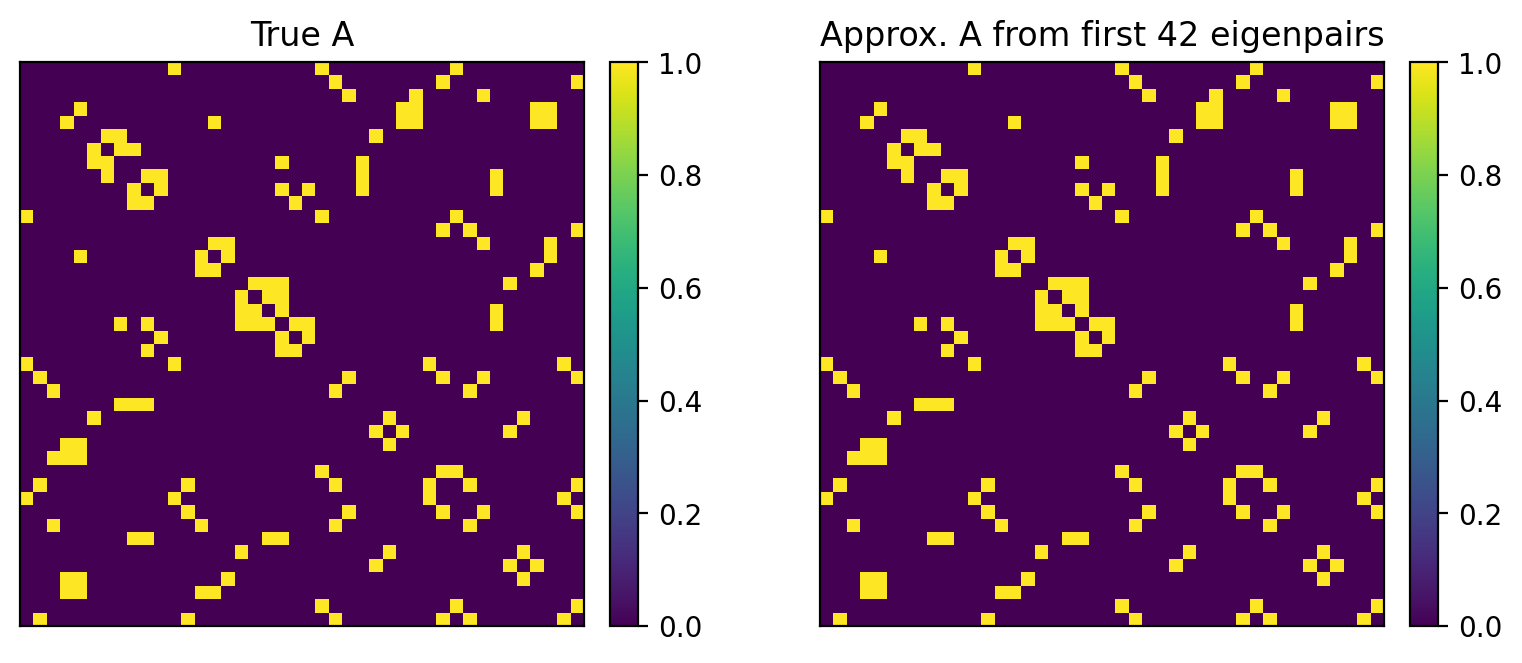

k = 200


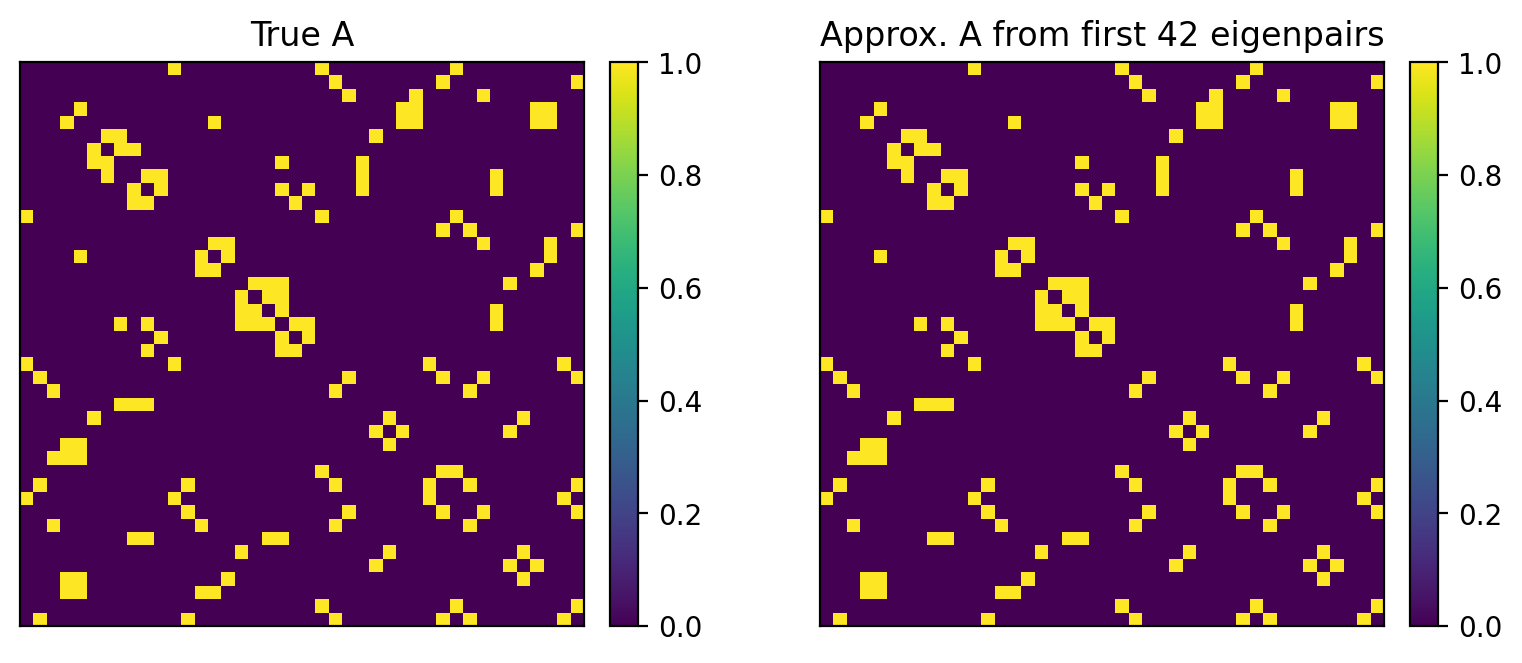

k = 400


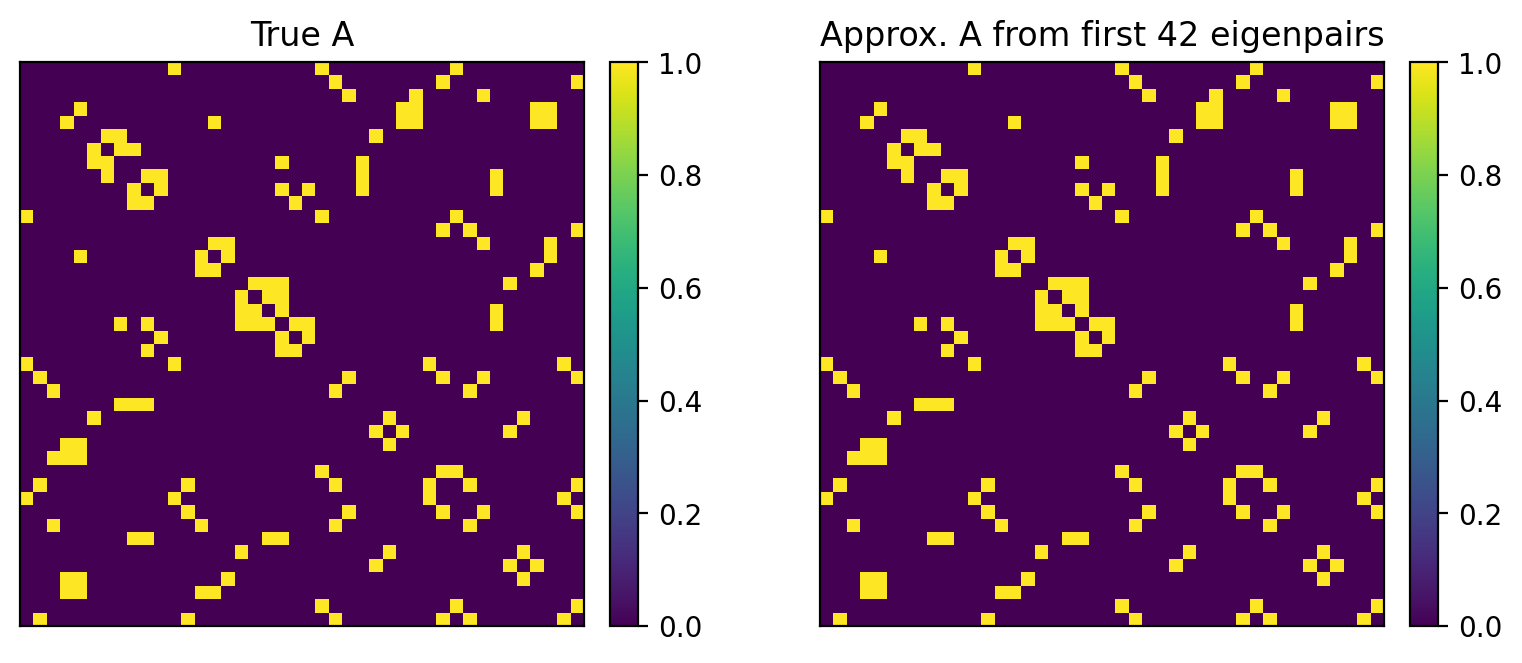

In [43]:
# --- Setup from your context -------------------------------------------------
# Assumes you already have: Gs (list of NetworkX graphs from PROTEINS)
import numpy as np, networkx as nx, matplotlib.pyplot as plt

idx = 0
G = Gs[idx]
n = G.number_of_nodes()

# --- 1) Core matrices --------------------------------------------------------
A = nx.to_numpy_array(G, dtype=float, nodelist=sorted(G.nodes()))  # (n,n)
deg = A.sum(1)                                                     # (n,)
D   = np.diag(deg)

# Safe degree-based scalings (handle deg=0)
eps = 1e-12
deg_clipped = np.clip(deg, eps, None)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg_clipped))   # D^{-1/2}
D_sqrt     = np.diag(np.sqrt(deg_clipped))         # D^{+1/2}

L = D - A
Lsym = np.eye(n) - D_inv_sqrt @ A @ D_inv_sqrt     # == D^{-1/2} L D^{-1/2}

# --- 2) Spectrum of L_sym ----------------------------------------------------
w, U = np.linalg.eigh(Lsym)                        # ascending eigenvalues
n_cc = int(np.isclose(w, 0.0, atol=1e-12).sum())

print(f"Graph #{idx}: n={n}, m={G.number_of_edges()}, "
      f"mean degree={deg.mean():.2f}, transitivity={nx.transitivity(G):.3f}")
print(f"L_sym eigenvalues in [0,2]; multiplicity of 0 = {n_cc} (components).")

# --- 3) Quick panels (A, D, L, L_sym, spectrum, first k eigenvectors) -------
def show_mat(M, ax, title):
    im = ax.imshow(M, interpolation="nearest", aspect="equal")
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

k_show = min(6, n)
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
show_mat(A,    axs[0,0], "Adjacency A (0/1)")
show_mat(D,    axs[0,1], "Degree matrix D")
show_mat(L,    axs[0,2], "Unnormalized Laplacian L = D − A")
show_mat(Lsym, axs[1,0], "Normalized Laplacian $L_{sym}=I−D^{-1/2}AD^{-1/2}$")

axs[1,1].hist(w, bins=30, range=(0,2))
axs[1,1].set_title("Eigenvalue histogram of $L_{sym}$")
axs[1,1].set_xlabel("λ"); axs[1,1].set_ylabel("freq")

axs[1,2].plot(U[:, :k_show])
axs[1,2].set_title(f"First {k_show} eigenvectors (columns of Φ)")
axs[1,2].set_xlabel("node index"); axs[1,2].set_ylabel("value")
plt.show()

# --- 4) Reconstruction error vs k (in L_sym space) --------------------------
def recon_error_vs_k(w, U, Lsym, ks=(2,4,8,12,16,24,32)):
    ks = [k for k in ks if k <= len(w)]
    errs = []
    for k in ks:
        Uk = U[:, :k]
        Lk_sym = (Uk * w[:k]) @ Uk.T     # Uk @ diag(w[:k]) @ Uk.T
        rel = np.linalg.norm(Lsym - Lk_sym, 'fro') / np.linalg.norm(Lsym, 'fro')
        errs.append((k, rel))
    return np.array(errs)

errs = recon_error_vs_k(w, U, Lsym)
plt.figure(figsize=(5,3.2))
plt.plot(errs[:,0], errs[:,1], marker='o')
plt.xlabel("# eigenpairs kept (k)")
plt.ylabel(r"relative error  $\|L_{sym}-L_k\|_F / \|L_{sym}\|_F$")
plt.title("Truncated spectrum reconstruction of $L_{sym}$")
plt.grid(True, alpha=0.3)
plt.show()

# --- 5) Build A_k correctly from the first k eigenpairs ---------------------
def approx_A_from_first_k(k, w, U, D, D_sqrt, A_true=None):
    k = min(k, len(w))
    Uk = U[:, :k]
    Lk_sym = (Uk * w[:k]) @ Uk.T           # Φ_k Λ_k Φ_k^T  in normalized space
    Lk_un  = D_sqrt @ Lk_sym @ D_sqrt      # unnormalize: L = D^{1/2} L_sym D^{1/2}
    Ak     = D - Lk_un                      # A = D - L
    # tidy up for viewing
    Ak = 0.5 * (Ak + Ak.T)                  # force symmetry
    np.fill_diagonal(Ak, 0.0)               # no self-loops in PROTEINS
    Ak = np.clip(Ak, 0.0, 1.0)              # just for visualization
    if A_true is not None:
        fig, ax = plt.subplots(1,2, figsize=(8,3.2), constrained_layout=True)
        show_mat(A_true, ax[0], "True A")
        show_mat(Ak,     ax[1], f"Approx. A from first {k} eigenpairs")
        plt.show()
    return Ak

# demo for a few k values
for k in [12, 30, 50, 100, 200, 400]:
    print(f"k = {k}")
    _ = approx_A_from_first_k(k, w, U, D, D_sqrt, A_true=A)
